In [1]:
import kagglehub
path = kagglehub.dataset_download("robikscube/hourly-energy-consumption")
print(path)

100%|██████████| 11.4M/11.4M [00:01<00:00, 7.38MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/robikscube/hourly-energy-consumption/versions/3


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [3]:
df = pd.read_csv(f"{path}/PJME_hourly.csv")
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [4]:
df.tail()

,PJME_MW
Datetime,
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0
2018-08-02 23:00:00,38500.0
2018-08-03 00:00:00,35486.0


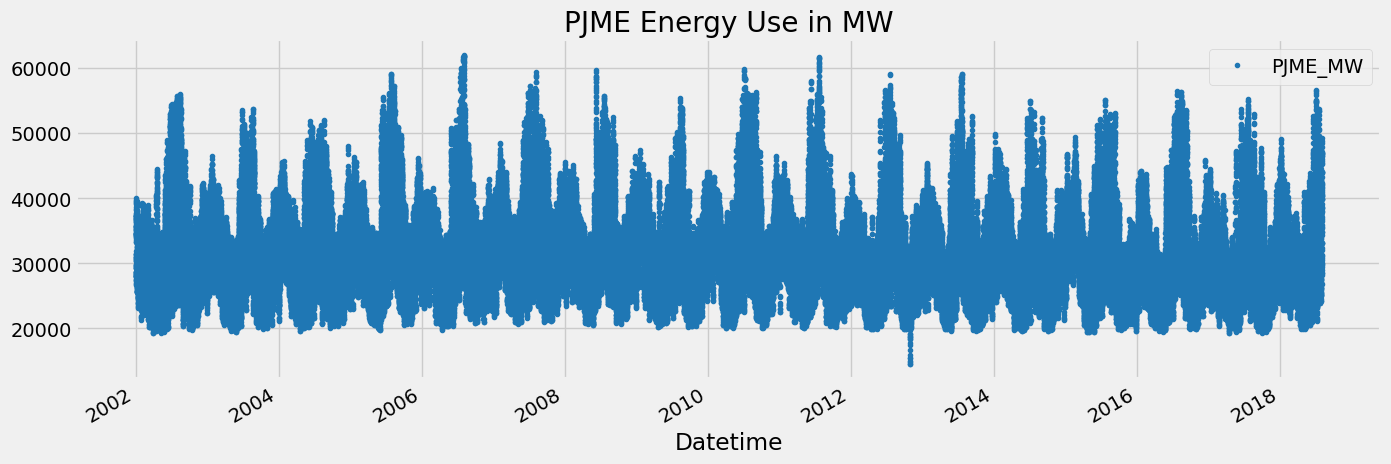

In [5]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='PJME Energy Use in MW')
plt.show()


# **Train / Test Split**

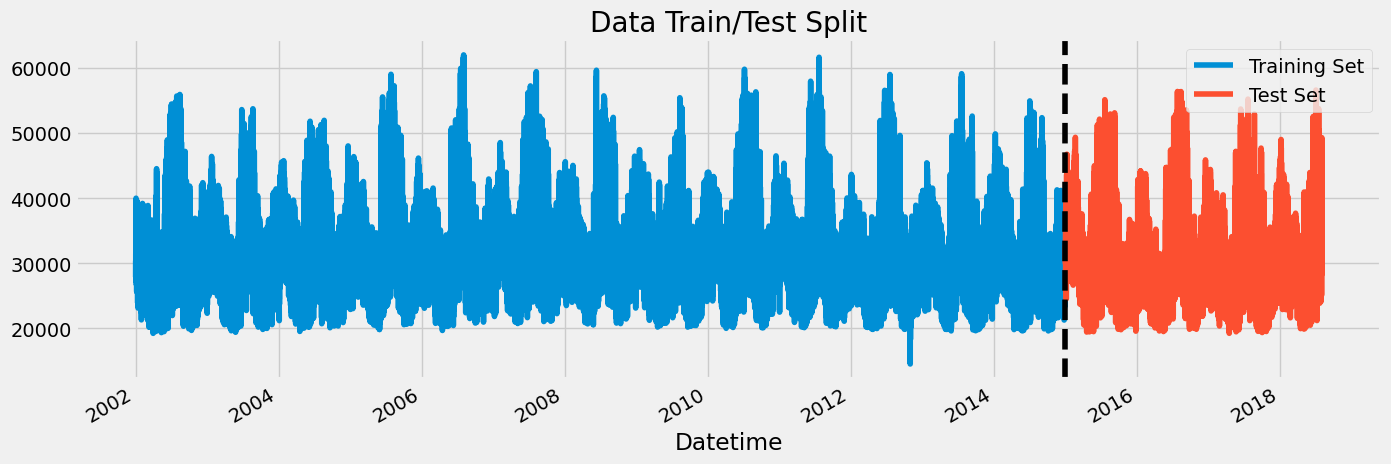

In [6]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

**One week of data visualization**

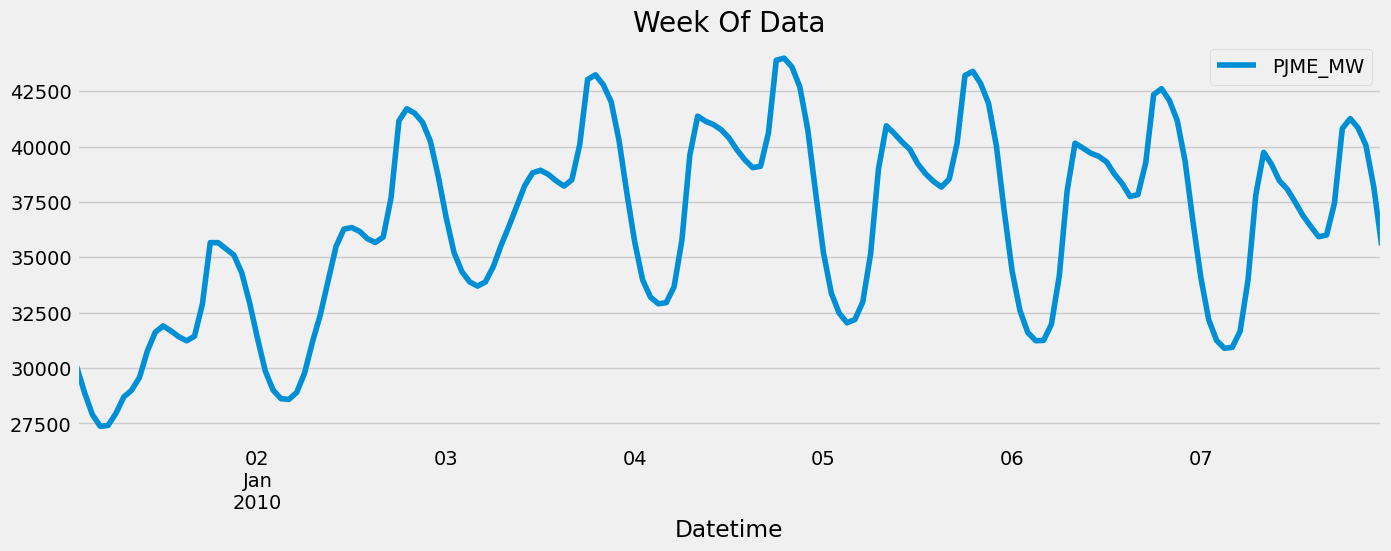

In [7]:
df.loc[(df.index > '01-01-2010') & (df.index < '01-08-2010')] \
    .plot(figsize=(15, 5), title='Week Of Data')
plt.show()

# **Feature Creation**

In [8]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

# **Visualizing the relationship between Feature and Target**

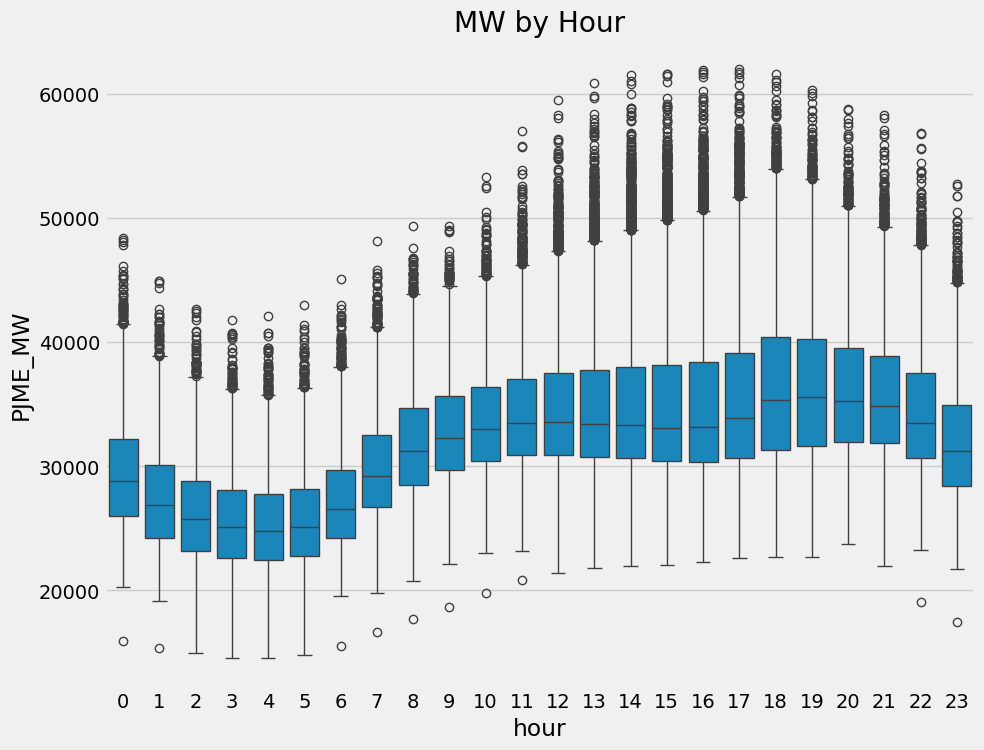

In [9]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='PJME_MW')
ax.set_title('MW by Hour')
plt.show()


# **Create Model**

In [10]:
train = create_features(train)
test = create_features(test)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year']
TARGET = 'PJME_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

In [11]:
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:32605.13605	validation_1-rmse:31657.15764


/usr/local/lib/python3.13/dist-packages/xgboost/callback.py:385: UserWarning: [11:34:09] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12584.38995	validation_1-rmse:11748.11856
[200]	validation_0-rmse:5836.77160	validation_1-rmse:5367.04436
[300]	validation_0-rmse:3926.66202	validation_1-rmse:4028.95967
[400]	validation_0-rmse:3448.41148	validation_1-rmse:3856.69750
[500]	validation_0-rmse:3287.85961	validation_1-rmse:3810.57566
[600]	validation_0-rmse:3205.22683	validation_1-rmse:3774.69216
[700]	validation_0-rmse:3150.34169	validation_1-rmse:3757.05520
[800]	validation_0-rmse:3110.70530	validation_1-rmse:3740.45591
[900]	validation_0-rmse:3080.90763	validation_1-rmse:3730.04135
[999]	validation_0-rmse:3054.21334	validation_1-rmse:3726.61186


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

# **Feature Importance**

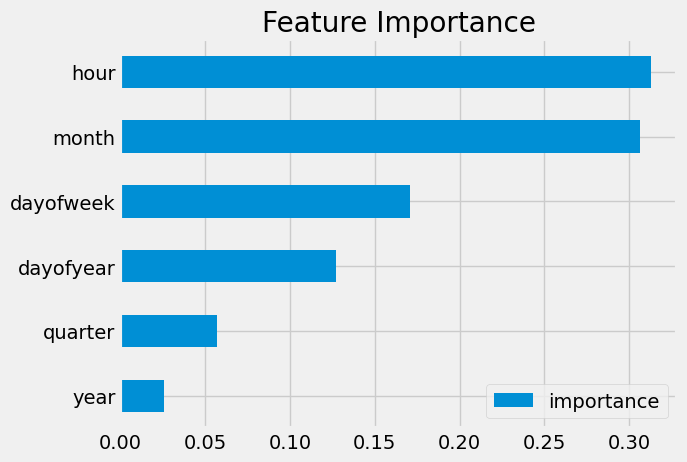

In [12]:
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()


# **Forecast on Test**

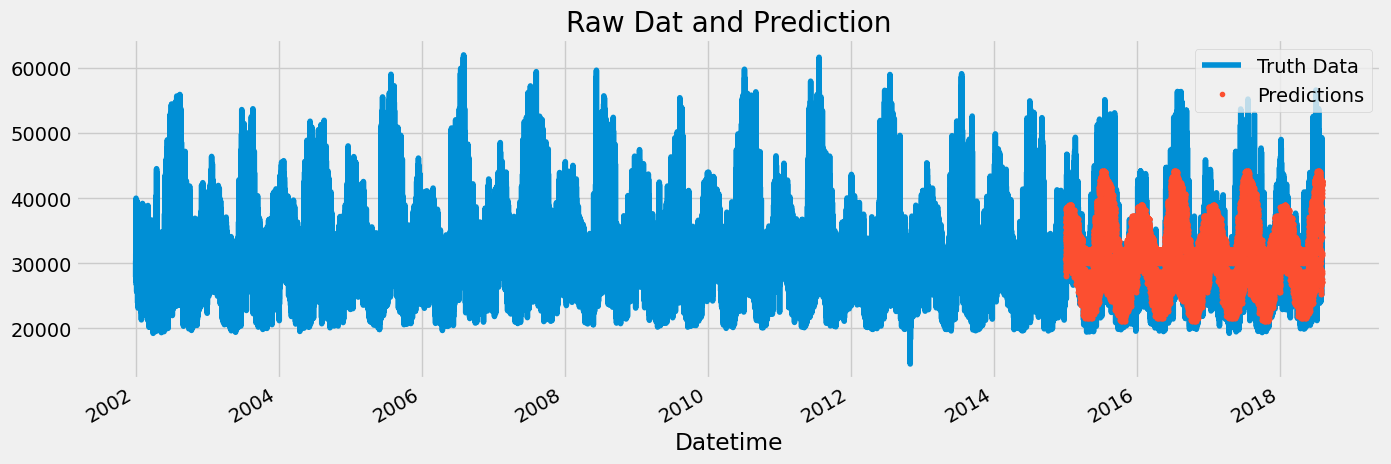

In [13]:
test['prediction'] = reg.predict(X_test)
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)
ax = df[['PJME_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()


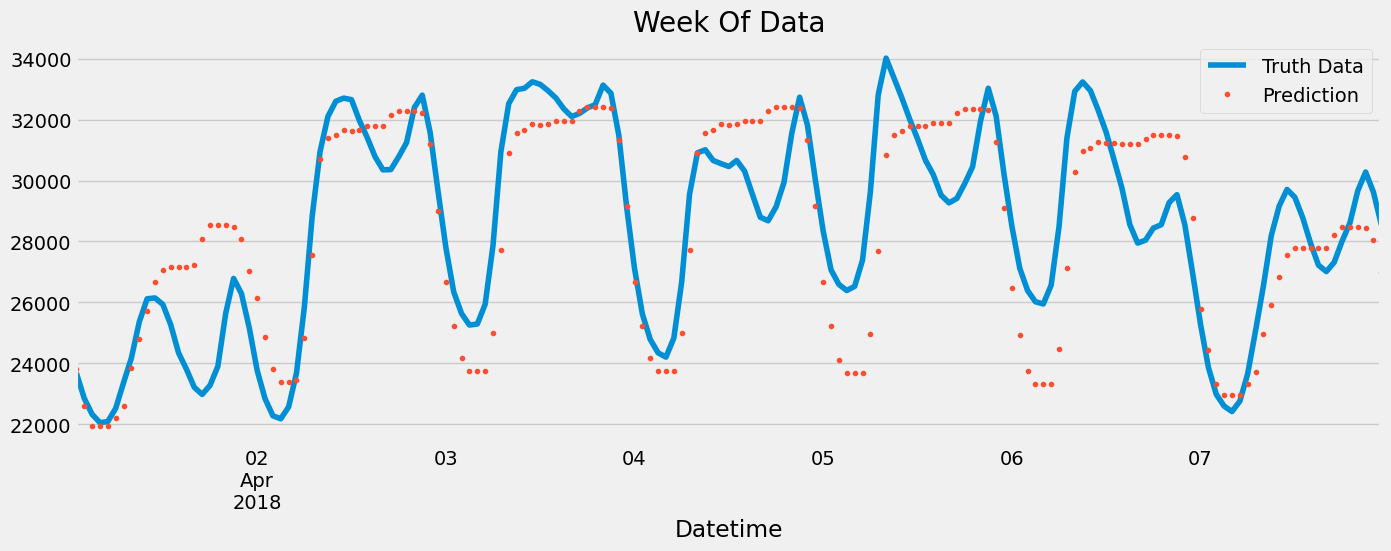

In [14]:
ax = df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['PJME_MW'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['prediction'] \
    .plot(style='.')
plt.legend(['Truth Data','Prediction'])
plt.show()

# **Score (RMSE)¶**

In [15]:
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

RMSE Score on Test set: 3726.50


# **Calculate Error**

In [16]:
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date
test.groupby(['date'])['error'].mean().sort_values(ascending=False).head(10)

,error
date,
2016-08-13,12792.355794
2016-08-14,12755.737467
2016-09-10,12165.990804
2015-02-20,11041.841146
2016-09-09,10840.006429
2018-01-06,10523.503174
2016-08-12,10035.958171
2015-02-21,9967.257812
2015-02-16,9834.920573


# **ADVANCED METHODS FOR PREDICTING**

# **1. Outlier Analysis and removal**

<Axes: ylabel='Frequency'>

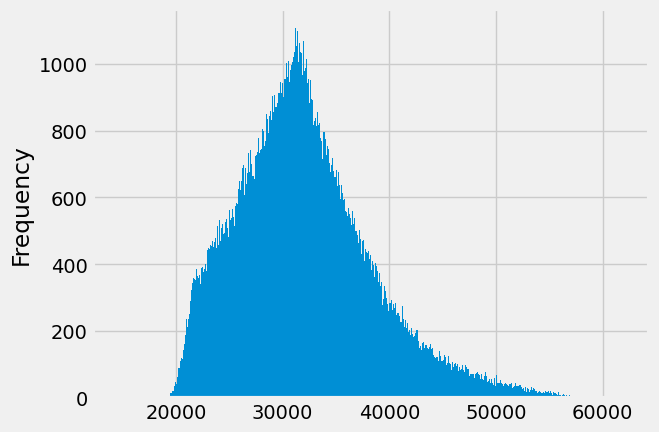

In [17]:
df['PJME_MW'].plot(kind='hist', bins=500)

<Axes: title={'center': 'Outliers'}, xlabel='Datetime'>

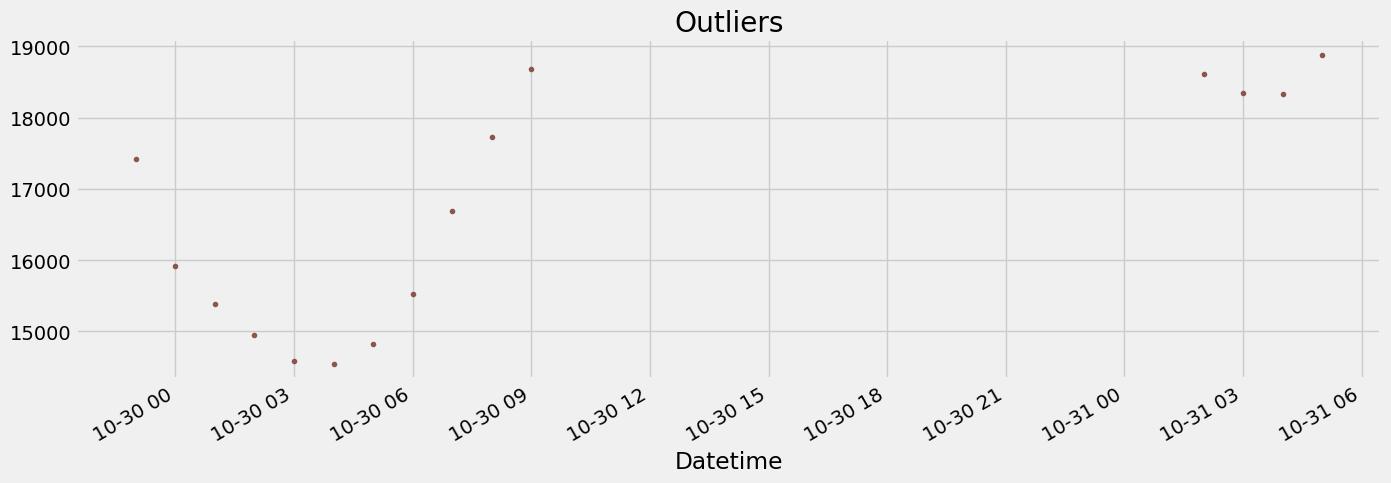

In [18]:
df.query('PJME_MW < 19_000')['PJME_MW'] \
    .plot(style='.',
          figsize=(15, 5),
          color=color_pal[5],
          title='Outliers')

In [19]:
df = df.query('PJME_MW > 19_000').copy()

# **1. Time Series Cross Validation**

In [20]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()

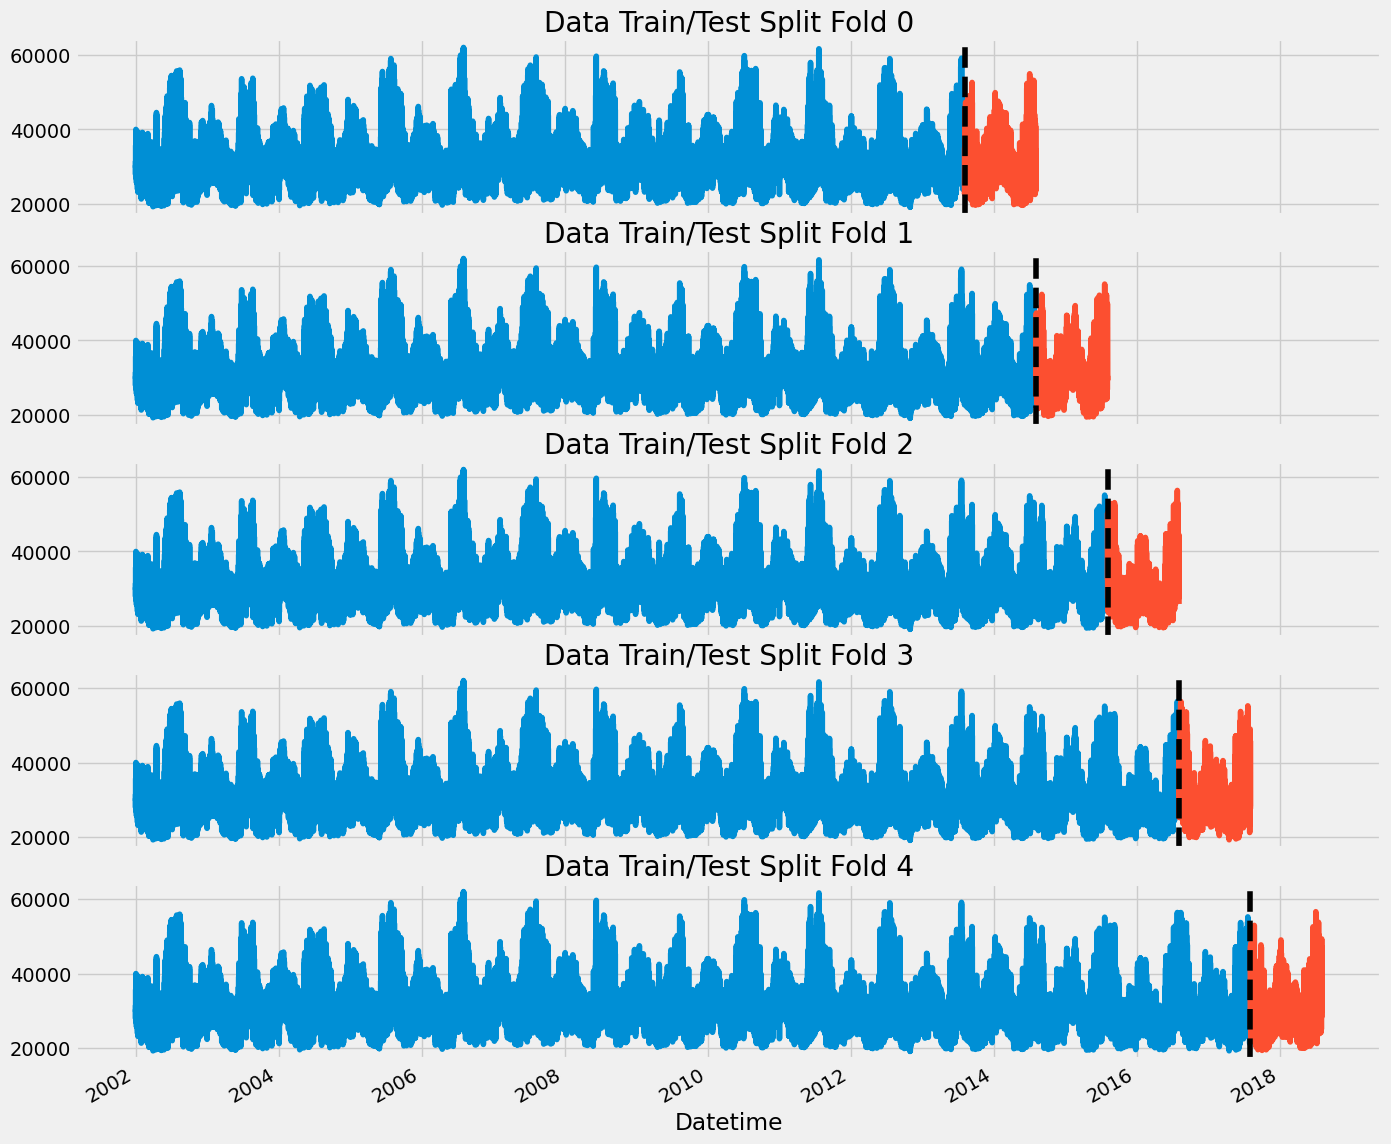

In [21]:
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['PJME_MW'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['PJME_MW'].plot(ax=axs[fold],
                         label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.show()

# **2. Forecasting Horizon Explained**

In [22]:
def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

df = create_features(df)

# **3. Lag Features**

In [23]:
def add_lags(df):
    target_map = df['PJME_MW'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('364 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('728 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('1092 days')).map(target_map)
    return df

In [24]:
df = add_lags(df)

# **Train Using Cross Validation**

In [25]:
tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()


fold = 0
preds = []
scores = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month','year',
                'lag1','lag2','lag3']
    TARGET = 'PJME_MW'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:linear',
                           max_depth=3,
                           learning_rate=0.01)
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

[0]	validation_0-rmse:32732.29937	validation_1-rmse:31956.12398


/usr/local/lib/python3.13/dist-packages/xgboost/callback.py:385: UserWarning: [11:34:29] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12532.82147	validation_1-rmse:11903.57779
[200]	validation_0-rmse:5743.20836	validation_1-rmse:5354.70463
[300]	validation_0-rmse:3867.61792	validation_1-rmse:3893.97231
[400]	validation_0-rmse:3430.82654	validation_1-rmse:3758.63909
[447]	validation_0-rmse:3360.53610	validation_1-rmse:3764.95666
[0]	validation_0-rmse:32671.76877	validation_1-rmse:32142.13659


/usr/local/lib/python3.13/dist-packages/xgboost/callback.py:385: UserWarning: [11:34:33] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12513.37975	validation_1-rmse:12226.15822
[200]	validation_0-rmse:5754.78366	validation_1-rmse:5658.04041
[300]	validation_0-rmse:3903.71369	validation_1-rmse:3930.69732
[400]	validation_0-rmse:3476.69022	validation_1-rmse:3596.92722
[500]	validation_0-rmse:3355.95434	validation_1-rmse:3528.53565
[600]	validation_0-rmse:3299.49445	validation_1-rmse:3489.98923
[700]	validation_0-rmse:3258.71976	validation_1-rmse:3464.73274
[800]	validation_0-rmse:3221.47910	validation_1-rmse:3441.24426
[900]	validation_0-rmse:3192.68839	validation_1-rmse:3433.92698
[999]	validation_0-rmse:3168.16411	validation_1-rmse:3426.84996
[0]	validation_0-rmse:32630.97820	validation_1-rmse:31069.98423


...

[100]	validation_0-rmse:12498.63860	validation_1-rmse:11133.90249
[200]	validation_0-rmse:5750.36631	validation_1-rmse:4813.33875
[300]	validation_0-rmse:3915.85173	validation_1-rmse:3542.43477
[400]	validation_0-rmse:3493.90220	validation_1-rmse:3487.24907
[412]	validation_0-rmse:3472.83462	validation_1-rmse:3494.84135
[0]	validation_0-rmse:32528.19057	validation_1-rmse:31474.52153


/usr/local/lib/python3.13/dist-packages/xgboost/callback.py:385: UserWarning: [11:34:50] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12462.40451	validation_1-rmse:12015.96172
[200]	validation_0-rmse:5737.12963	validation_1-rmse:5790.10564
[300]	validation_0-rmse:3914.92694	validation_1-rmse:4379.83020
[400]	validation_0-rmse:3497.65187	validation_1-rmse:4169.39877
[500]	validation_0-rmse:3383.19047	validation_1-rmse:4118.76887
[537]	validation_0-rmse:3358.73900	validation_1-rmse:4115.89141
[0]	validation_0-rmse:32461.76390	validation_1-rmse:31462.57470


/usr/local/lib/python3.13/dist-packages/xgboost/callback.py:385: UserWarning: [11:34:57] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12445.83546	validation_1-rmse:11958.14517
[200]	validation_0-rmse:5752.06963	validation_1-rmse:5609.22021
[300]	validation_0-rmse:3951.44913	validation_1-rmse:4148.45760
[400]	validation_0-rmse:3540.14041	validation_1-rmse:3995.19985
[441]	validation_0-rmse:3481.44857	validation_1-rmse:4004.85848


In [26]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 3752.1850
Fold scores:[np.float64(3757.541476981005), np.float64(3426.4164853762363), np.float64(3468.3573488886336), np.float64(4114.9220288448605), np.float64(3993.6877717169723)]


# **4. Predicting the Future**

In [27]:
df = create_features(df)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year',
            'lag1','lag2','lag3']
TARGET = 'PJME_MW'

X_all = df[FEATURES]
y_all = df[TARGET]

reg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',
                       n_estimators=500,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_all, y_all,
        eval_set=[(X_all, y_all)],
        verbose=100)

[0]	validation_0-rmse:32403.50192


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [11:35:03] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:275: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-rmse:12426.68909
[200]	validation_0-rmse:5753.04641
[300]	validation_0-rmse:3972.98404
[400]	validation_0-rmse:3572.12794
[499]	validation_0-rmse:3458.09393


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [28]:
df.index.max()

Timestamp('2018-08-03 00:00:00')

In [29]:
# Create future dataframe
future = pd.date_range('2018-08-03','2019-08-01', freq='1h')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)

In [30]:
future_w_features = df_and_future.query('isFuture').copy()

**Predict the future**

In [31]:
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])

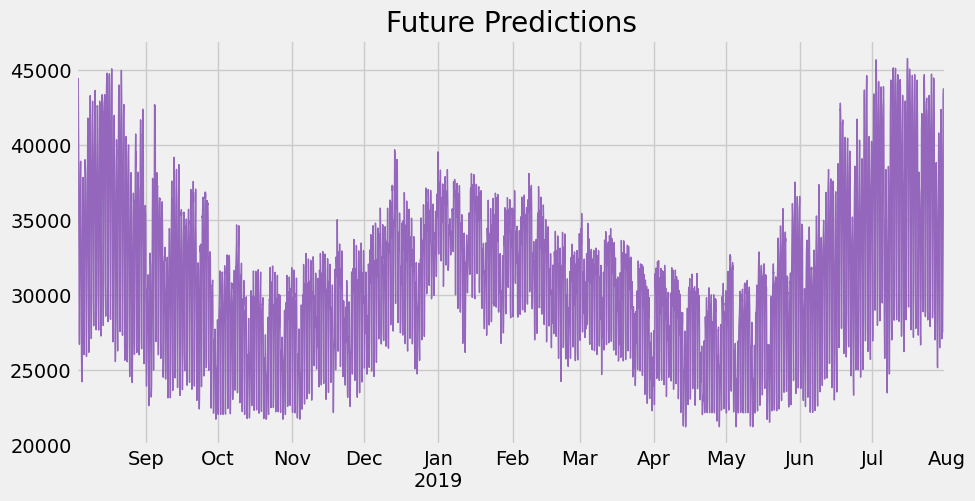

In [32]:
future_w_features['pred'].plot(figsize=(10, 5),
                               color=color_pal[4],
                               ms=1,
                               lw=1,
                               title='Future Predictions')
plt.show()

# **Anamoly detection using IQR (Interquartile Range) method**

Total observations: 145,357
Number of anomalies: 2,590
Percentage of anomalies: 1.78%

Preview of detected anomalies:


,PJME_MW,hour,Lower_Bound,Upper_Bound,anomaly
Datetime,,,,,
2002-06-24 13:00:00,48937.0,13,20299.625,48188.625,True
2002-06-24 14:00:00,50207.0,14,19599.625,49036.625,True
2002-06-24 15:00:00,50783.0,15,18727.875,49848.875,True
2002-06-24 16:00:00,51148.0,16,18127.625,50610.625,True
2002-06-25 13:00:00,48374.0,13,20299.625,48188.625,True
2002-06-25 14:00:00,49643.0,14,19599.625,49036.625,True
2002-06-25 15:00:00,50311.0,15,18727.875,49848.875,True
2002-06-25 16:00:00,50967.0,16,18127.625,50610.625,True
2002-06-26 11:00:00,48034.0,11,21693.500,46241.500,True


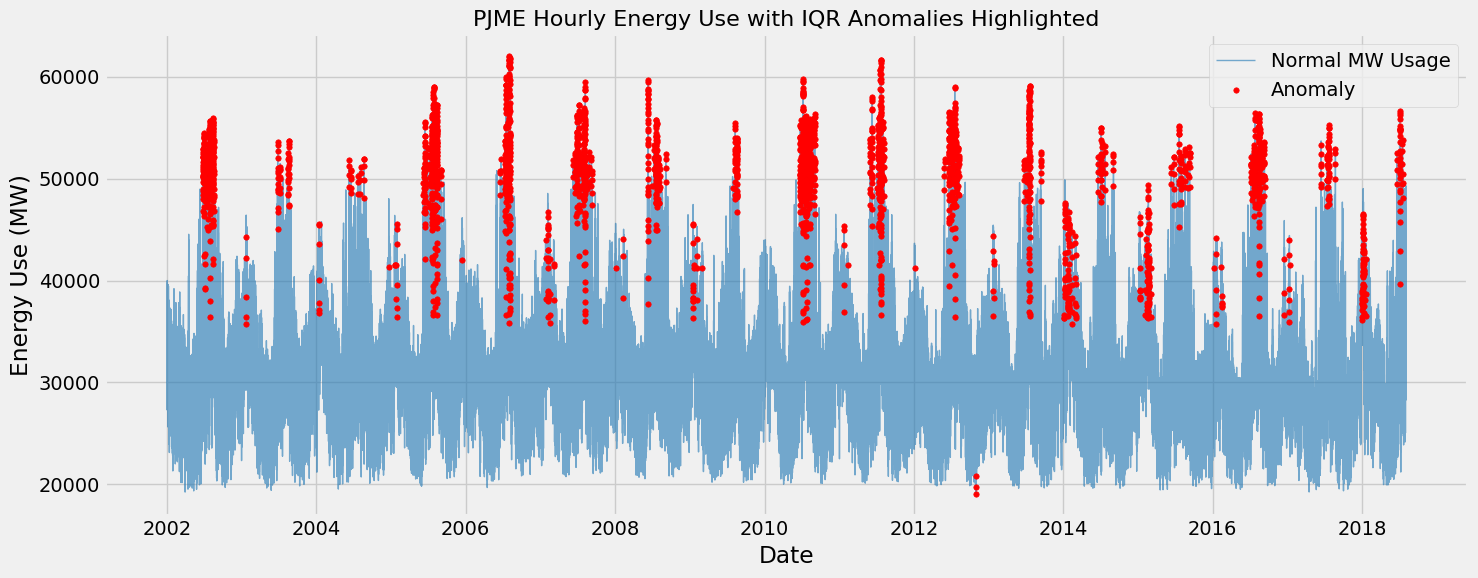

In [33]:
# 1. Calculate Q1, Q3, and IQR separately for each hour of the day
hourly_stats = df.groupby('hour')['PJME_MW'].agg(
    Q1=lambda x: x.quantile(0.25),
    Q3=lambda x: x.quantile(0.75)
)

# Calculate the Interquartile Range (IQR) and boundaries
hourly_stats['IQR'] = hourly_stats['Q3'] - hourly_stats['Q1']
hourly_stats['Lower_Bound'] = hourly_stats['Q1'] - 1.5 * hourly_stats['IQR']
hourly_stats['Upper_Bound'] = hourly_stats['Q3'] + 1.5 * hourly_stats['IQR']

# 2. Map the calculated bounds back to the original DataFrame
df['Lower_Bound'] = df['hour'].map(hourly_stats['Lower_Bound'])
df['Upper_Bound'] = df['hour'].map(hourly_stats['Upper_Bound'])

# 3. Create the boolean 'anomaly' column
df['anomaly'] = (df['PJME_MW'] < df['Lower_Bound']) | (df['PJME_MW'] > df['Upper_Bound'])

# 4. Isolate the anomalous data into its own DataFrame (This prevents the NameError)
anomalous_data = df[df['anomaly']]

# Calculate and display summary statistics
total_obs = len(df)
total_anomalies = df['anomaly'].sum()
percent_anomalies = (total_anomalies / total_obs) * 100

print(f"Total observations: {total_obs:,}")
print(f"Number of anomalies: {total_anomalies:,}")
print(f"Percentage of anomalies: {percent_anomalies:.2f}%\n")

print("Preview of detected anomalies:")
display(anomalous_data[['PJME_MW', 'hour', 'Lower_Bound', 'Upper_Bound', 'anomaly']].head(10))

# 5. Create a time-series visualization highlighting the anomalies
fig, ax = plt.subplots(figsize=(15, 6))

# Plot the normal data first
ax.plot(df.index, df['PJME_MW'], label='Normal MW Usage', color=color_pal[0], alpha=0.6, linewidth=1)

# Overlay the anomalous data using a scatter plot
ax.scatter(anomalous_data.index, anomalous_data['PJME_MW'], color='red', label='Anomaly', s=15, zorder=3)

# Formatting the plot
ax.set_title('PJME Hourly Energy Use with IQR Anomalies Highlighted', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Energy Use (MW)')
ax.legend()

plt.tight_layout()
plt.show()

# **Anamoly Detection using Isolation Forest**

--- Isolation Forest Anomaly Detection ---
Total observations: 145,357
Number of anomalies: 1,450
Percentage of anomalies: 1.00%

Preview of detected anomalies:


,PJME_MW,hour,if_score,anomaly_if
Datetime,,,,
2002-06-26 13:00:00,51677.0,13,-1,True
2002-06-26 14:00:00,52637.0,14,-1,True
2002-06-26 15:00:00,52938.0,15,-1,True
2002-06-26 16:00:00,52894.0,16,-1,True
2002-06-27 14:00:00,51362.0,14,-1,True
2002-07-02 14:00:00,52336.0,14,-1,True
2002-07-02 15:00:00,53405.0,15,-1,True
2002-07-02 16:00:00,53992.0,16,-1,True
2002-07-02 17:00:00,54352.0,17,-1,True


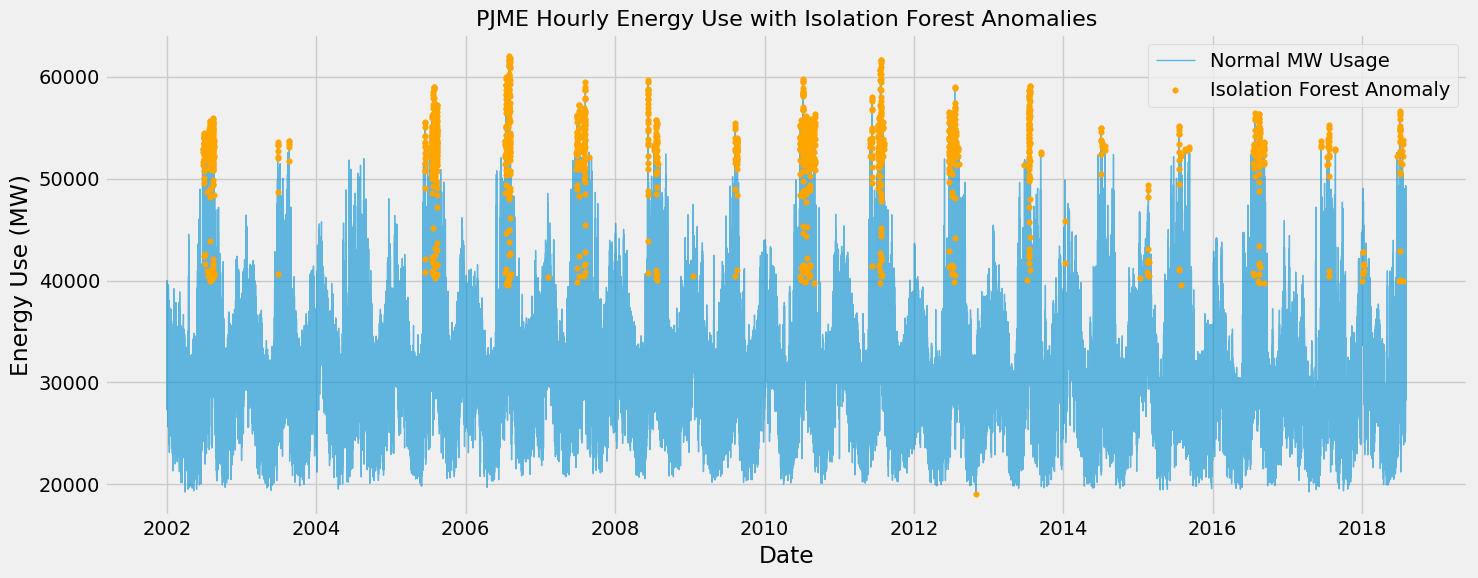

In [34]:
# 0. Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import IsolationForest

color_pal = sns.color_palette()

# 1. Prepare the features for the Isolation Forest
# We pass both the energy use and the hour so the model learns their relationship
features = ['PJME_MW', 'hour']
X = df[features]

# 2. Initialize the Isolation Forest model
# 'contamination' sets the expected percentage of anomalies in the dataset.
# We are setting it to 0.01 (1%) to flag only the most extreme outliers.
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# 3. Fit the model and predict anomalies
# Isolation Forest returns 1 for normal observations and -1 for anomalies
df['if_score'] = iso_forest.fit_predict(X)

# Convert the -1/1 output into a boolean column (True if anomaly, False if normal)
df['anomaly_if'] = df['if_score'] == -1

# 4. Isolate the anomalous data into its own DataFrame
anomalous_data_if = df[df['anomaly_if']]

# Calculate and display summary statistics
total_obs = len(df)
total_anomalies = df['anomaly_if'].sum()
percent_anomalies = (total_anomalies / total_obs) * 100

print("--- Isolation Forest Anomaly Detection ---")
print(f"Total observations: {total_obs:,}")
print(f"Number of anomalies: {total_anomalies:,}")
print(f"Percentage of anomalies: {percent_anomalies:.2f}%\n")

print("Preview of detected anomalies:")
display(anomalous_data_if[['PJME_MW', 'hour', 'if_score', 'anomaly_if']].head(10))

# 5. Create a time-series visualization highlighting the anomalies
fig, ax = plt.subplots(figsize=(15, 6))

# Plot the normal data first
ax.plot(df.index, df['PJME_MW'], label='Normal MW Usage', color=color_pal[0], alpha=0.6, linewidth=1)

# Overlay the anomalous data using a scatter plot
# Using orange this time to distinguish it from the previous IQR plot
ax.scatter(anomalous_data_if.index, anomalous_data_if['PJME_MW'], color='orange', label='Isolation Forest Anomaly', s=15, zorder=3)

# Formatting the plot
ax.set_title('PJME Hourly Energy Use with Isolation Forest Anomalies', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Energy Use (MW)')
ax.legend()

plt.tight_layout()
plt.show()

# **Comparing the Anomaly Detection between IQR and Isolation Forest**

--- Anomaly Detection Comparison ---
Total Anomalies (Hourly IQR): 2,590
Total Anomalies (Isolation Forest): 1,454
Detected by BOTH: 416
Detected by IQR ONLY: 2,174
Detected by IF ONLY: 1,038

Cross-Tabulation of Anomalies:


,Normal (IF),Anomaly (IF)
Normal (IQR),141729,1038
Anomaly (IQR),2174,416


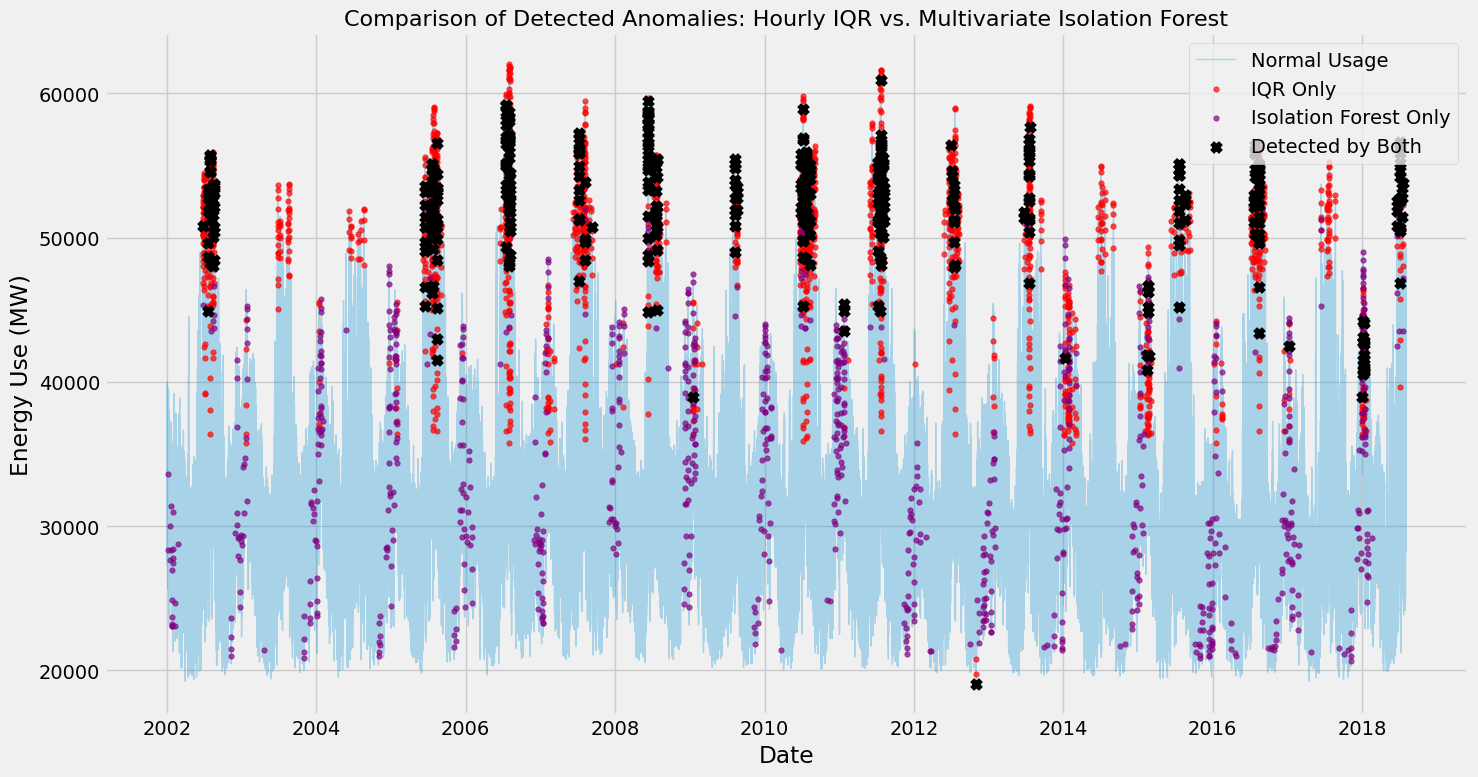

In [36]:
# 1. Categorize the anomalies
# Check where both are True, where only IQR is True, and where only IF is True
df['both_anomaly'] = df['anomaly'] & df['anomaly_if_multi']
df['iqr_only'] = df['anomaly'] & ~df['anomaly_if_multi']
df['if_only'] = ~df['anomaly'] & df['anomaly_if_multi']

# 2. Print Summary Statistics
print("--- Anomaly Detection Comparison ---")
print(f"Total Anomalies (Hourly IQR): {df['anomaly'].sum():,}")
print(f"Total Anomalies (Isolation Forest): {df['anomaly_if_multi'].sum():,}")
print(f"Detected by BOTH: {df['both_anomaly'].sum():,}")
print(f"Detected by IQR ONLY: {df['iqr_only'].sum():,}")
print(f"Detected by IF ONLY: {df['if_only'].sum():,}\n")

# Create a cross-tabulation (Confusion Matrix style) for a clean summary
print("Cross-Tabulation of Anomalies:")
crosstab = pd.crosstab(
    df['anomaly'],
    df['anomaly_if_multi'],
    rownames=['Hourly IQR'],
    colnames=['Isolation Forest']
)
# Rename the True/False indices for better readability
crosstab.index = ['Normal (IQR)', 'Anomaly (IQR)']
crosstab.columns = ['Normal (IF)', 'Anomaly (IF)']
display(crosstab)

# 3. Create a unified comparison visualization
fig, ax = plt.subplots(figsize=(15, 8))

# Plot the normal data in the background (very faint so anomalies stand out)
ax.plot(df.index, df['PJME_MW'], label='Normal Usage', color=color_pal[0], alpha=0.3, linewidth=1)

# Scatter plot for IQR ONLY (Red)
iqr_only_data = df[df['iqr_only']]
ax.scatter(iqr_only_data.index, iqr_only_data['PJME_MW'],
           color='red', label='IQR Only', s=15, alpha=0.7, zorder=2)

# Scatter plot for Isolation Forest ONLY (Purple)
if_only_data = df[df['if_only']]
ax.scatter(if_only_data.index, if_only_data['PJME_MW'],
           color='purple', label='Isolation Forest Only', s=15, alpha=0.7, zorder=2)

# Scatter plot for anomalies detected by BOTH (Black 'X')
both_data = df[df['both_anomaly']]
ax.scatter(both_data.index, both_data['PJME_MW'],
           color='black', label='Detected by Both', s=40, marker='x', zorder=3)

# Formatting the plot
ax.set_title('Comparison of Detected Anomalies: Hourly IQR vs. Multivariate Isolation Forest', fontsize=16)
ax.set_xlabel('Date')
ax.set_ylabel('Energy Use (MW)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()